<a href="https://colab.research.google.com/github/ganeshchoudari09/Machine_Learning/blob/main/SKILL/skill1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Saving titanic.csv to titanic (1).csv


In [10]:
df = pd.read_csv("titanic.csv")

print("First 5 Rows")
print(df.head())

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nInformation")
df.info()

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

First 5 Rows
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Shape
(891, 15)

Columns
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='

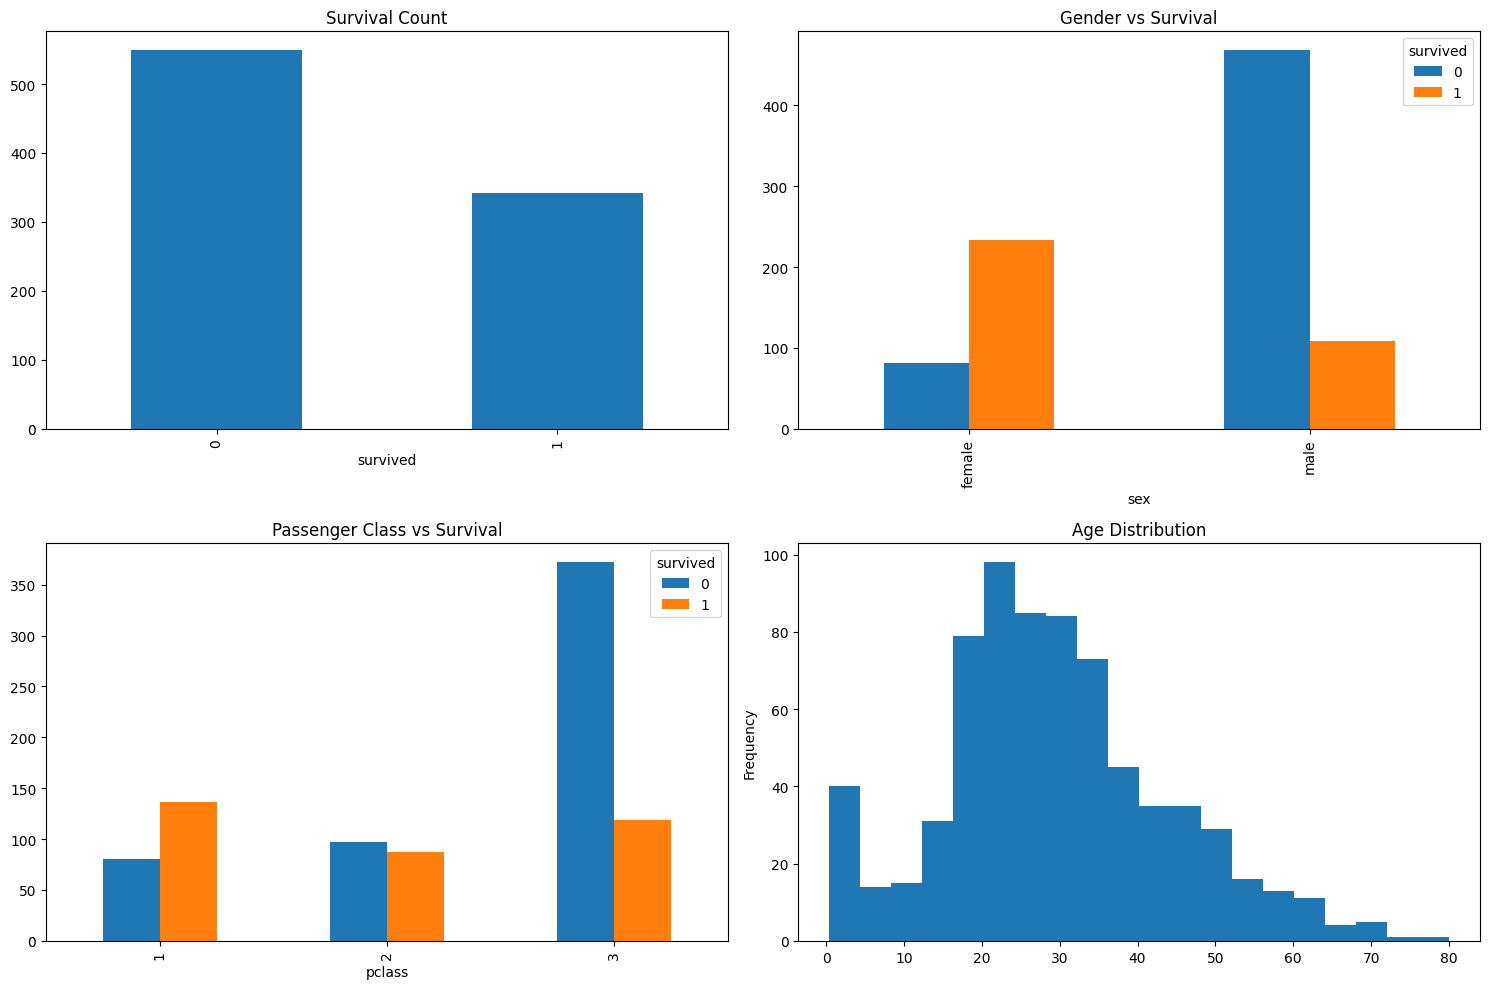

In [11]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
df["survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")

plt.subplot(2,2,2)
pd.crosstab(df["sex"], df["survived"]).plot(kind="bar", ax=plt.gca())
plt.title("Gender vs Survival")

plt.subplot(2,2,3)
pd.crosstab(df["pclass"], df["survived"]).plot(kind="bar", ax=plt.gca())
plt.title("Passenger Class vs Survival")

plt.subplot(2,2,4)
df["age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")

plt.tight_layout()
plt.show()

In [12]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

if "deck" in df.columns:
    df.drop("deck", axis=1, inplace=True)

df["sex"] = df["sex"].map({"male":0, "female":1})
df["embarked"] = df["embarked"].map({"S":0, "C":1, "Q":2})

X = df[["pclass","sex","age","sibsp","parch","fare","embarked"]]
y = df["survived"]

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

Accuracy: 0.7988826815642458

Confusion Matrix
[[89 16]
 [20 54]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [15]:
new_passenger = [[3, 0, 25, 0, 0, 7.25, 0]]

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger is likely to Survive")
else:
    print("Passenger is likely to Not Survive")

Passenger is likely to Not Survive


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
